# Model 4 -- SMEFT Warsaw basis: a smooth fit and an exposed degeneracy

B. Grzadkowski, M. Iskrzynski, M. Misiak, J. Rosiek, *JHEP* **10** (2010), arXiv:1008.4884.


The Standard Model Effective Field Theory parameterizes new physics too heavy to produce directly as a tower of higher-dimensional operators built from Standard Model fields, and the Warsaw basis is the standard dimension-six operator basis used in LEP/LHC precision fits. This benchmark scans ten Wilson coefficients touching the Higgs, the electroweak oblique parameters $S$ and $T$, and the gluon/photon Higgs couplings, at a fixed cutoff scale $\Lambda$.

**What this notebook does.** BSMScanner separates *what a model is* (a declarative YAML specification: parameters, priors, derived quantities, observables, validity conditions, likelihoods) from *how it is scanned* (one of several interchangeable search engines). This notebook loads the model below, runs a small, fast scan live so you can see the mechanics end to end, and then loads the matched-budget, fixed-seed comparison across all four engines from the companion paper's benchmark study, together with its best-fit / allowed-region result and figure. The live demo uses a short budget and an illustrative seed — it is not the published comparison, and is not expected to reproduce it exactly.


## 1. Load the framework and the model

In [1]:
import sys, pathlib
REPO_ROOT = pathlib.Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT / "python"))

import pandas as pd
from bsm_scanner import load_model, compile_model, run_scan
import bsm_scanner

print("bsm_scanner", bsm_scanner.__version__)
print("repo root  :", REPO_ROOT)

bsm_scanner 0.1.2
repo root  : /sessions/rcw-012reqeed7ksc6e9zagwhruw/mnt/BSMScanner


## 2. The model specification

Every scanned parameter, its prior, and its range come straight out of the model's YAML file (`../models/smeft_wilson/model.yaml`); nothing here is hand-written Python.

In [2]:
model = load_model("../models/smeft_wilson/model.yaml")
print("model    :", model.metadata.name)
print("params   :", len(model.parameters), "scanned")
print("theory checks:", len(model.theory_checks))
print("likelihood terms:", len(model.likelihoods))

pd.DataFrame(
    [{"name": p.name, "prior": p.prior.value, "lower": p.lower, "upper": p.upper, "default": p.default}
     for p in model.parameters]
)

model    : smeft_warsaw_dimension6
params   : 10 scanned
theory checks: 2
likelihood terms: 4


,name,prior,lower,upper,default
0,LambdaTeV,log,1.0,20.0,3.0
1,cH,flat,-10.0,10.0,0.0
2,cT,flat,-2.0,2.0,0.0
3,cWB,flat,-2.0,2.0,0.0
4,cGG,flat,-5.0,5.0,0.0
5,cWW,flat,-5.0,5.0,0.0
6,cBB,flat,-5.0,5.0,0.0
7,cy_t,flat,-5.0,5.0,0.0
8,cy_b,flat,-5.0,5.0,0.0
9,cy_tau,flat,-5.0,5.0,0.0


Likelihood terms declared on the model:

In [3]:
pd.DataFrame(
    [{"name": t.name, "kind": t.kind.value, "observable": t.observable} for t in model.likelihoods]
)

,name,kind,observable
0,S_constraint,gaussian,ObliqueSProxy
1,T_constraint,gaussian,ObliqueTProxy
2,mu_ggF_constraint,gaussian,HiggsMuGGFProxy
3,mu_gammagamma_constraint,gaussian,HiggsMuGammaGammaProxy


For reference, here is the parameter block exactly as written in the YAML (this is the entire declarative input the physics below is built from):

In [4]:
print(pathlib.Path("../models/smeft_wilson/model.yaml").read_text())

metadata:
  name: smeft_warsaw_dimension6
  version: 0.1.0
  description: Warsaw-basis dimension-six SMEFT benchmark with electroweak and Higgs-rate proxy observables at fixed Lambda.
  tags: [smeft, warsaw_basis, dimension_six, wilson_coefficients]
parameters:
- {name: LambdaTeV, value_type: real, scan: true, lower: 1.0, upper: 20.0, default: 3.0, prior: log}
- {name: cH, value_type: real, scan: true, lower: -10.0, upper: 10.0, default: 0.0, prior: flat}
- {name: cT, value_type: real, scan: true, lower: -2.0, upper: 2.0, default: 0.0, prior: flat}
- {name: cWB, value_type: real, scan: true, lower: -2.0, upper: 2.0, default: 0.0, prior: flat}
- {name: cGG, value_type: real, scan: true, lower: -5.0, upper: 5.0, default: 0.0, prior: flat}
- {name: cWW, value_type: real, scan: true, lower: -5.0, upper: 5.0, default: 0.0, prior: flat}
- {name: cBB, value_type: real, scan: true, lower: -5.0, upper: 5.0, default: 0.0, prior: flat}
- {name: cy_t, value_type: real, scan: true, lower: -5.0, upp

## 3. A quick, live scan

This runs `serial_random` for `3000` evaluations at a throwaway seed, right here, so you can see the mechanics end to end in a few seconds. It is deliberately small and is **not** the matched-budget comparison used in the study below.

In [5]:
# A small, fast, live demo -- NOT the matched-budget study below.
model.scan.engine = "serial_random"
model.scan.seed = 1
model.scan.settings["max_evaluations"] = 3000

compiled = compile_model(model)
demo = run_scan(model, compiled, run_directory="runs/smeft_wilson_demo")

n_eval = demo.summary["evaluations"]
n_valid = demo.summary["valid_points"]
print("evaluations  :", n_eval)
print("valid points :", n_valid, "(%.1f%% of this quick run)" % (100.0 * n_valid / n_eval))
print("best nLL in this quick run:", demo.summary["best_metric_value"])

points = pd.read_csv(demo.points_path)
points.head()

evaluations  : 3000
valid points : 3000 (100.0% of this quick run)
best nLL in this quick run: 0.04803659888853083


,evaluation,status,valid,failure_reason,scanner_target,metric_value,total_nll,param::LambdaTeV,param::cH,param::cT,...,output::ObliqueSProxy,output::ObliqueTProxy,output::HiggsMuGGFProxy,output::HiggsMuGammaGammaProxy,output::KappaBProxy,output::KappaTauProxy,likelihood::S_constraint,likelihood::T_constraint,likelihood::mu_gammagamma_constraint,likelihood::mu_ggF_constraint
0,1,ok,True,NaN,41.028500,41.028500,41.028500,1.49340,-7.27186,-0.195140,...,-0.208317,0.339351,0.191224,1.613393,1.018986,1.036759,1.253220,3.998580,13.064300,22.712500
1,2,ok,True,NaN,249.807000,249.807000,249.807000,1.30732,1.12358,1.158610,...,-0.157987,-2.629244,0.556805,0.738627,0.990988,0.918393,0.583057,240.032000,2.372080,6.820200
2,3,ok,True,NaN,10.798700,10.798700,10.798700,2.35586,4.97982,-0.167502,...,-0.033873,0.117052,0.489631,0.809079,1.021274,1.016144,0.013004,0.475734,1.265660,9.044330
3,4,ok,True,NaN,0.176905,0.176905,0.176905,10.66800,-2.14952,0.119749,...,-0.000866,-0.004081,0.960553,1.006764,0.997541,0.998845,0.120706,0.000578,0.001589,0.054031
4,5,ok,True,NaN,0.115847,0.115847,0.115847,14.18430,-4.76450,0.081940,...,-0.002316,-0.001580,1.004520,1.006269,1.001122,0.998982,0.113686,0.000087,0.001365,0.000709


## 4. The published engine comparison

Matched budget (~30k), identical seed (20260816). Four Gaussian terms, no hard cuts -- both theory checks are inactive by construction, so every engine ran at **100% validity**, the first model in the study with no validity boundary at all. The first genuinely smooth fit in the set.

In [6]:
pd.DataFrame([{'engine': 'serial_random', 'evaluations': 30000, 'valid_pct': '100%', 'best_nLL': '4.59e-02', 'evals_to_1e-3': 'never'}, {'engine': 'de_scipy', 'evaluations': 51599, 'valid_pct': '100%', 'best_nLL': '4.67e-13', 'evals_to_1e-3': 21042}, {'engine': 'adaptive_diver', 'evaluations': 26300, 'valid_pct': '100%', 'best_nLL': '4.23e-17', 'evals_to_1e-3': 2304}, {'engine': 'basin_scan', 'evaluations': 18661, 'valid_pct': '100%', 'best_nLL': '2.60e-09', 'evals_to_1e-3': 15001}])[['engine', 'evaluations', 'valid_pct', 'best_nLL', 'evals_to_1e-3']]

,engine,evaluations,valid_pct,best_nLL,evals_to_1e-3
0,serial_random,30000,100%,4.59e-02,never
1,de_scipy,51599,100%,4.67e-13,21042
2,adaptive_diver,26300,100%,4.23e-17,2304
3,basin_scan,18661,100%,2.60e-09,15001


`adaptive_diver` wins by a wide margin on speed, reaching $n$LL$<10^{-3}$ in 2,304 evaluations against 21,042 for `de_scipy` and 15,001 for `basin_scan`. `serial_random` never gets close (best 0.046) -- with validity at 100%, this is the cleanest demonstration in the study of why random scanning fails purely from search-efficiency as dimensionality grows, with no validity effect to blame.

## 5. Best fit

In [7]:
pd.DataFrame([{'observable': 'S proxy', 'best_fit': -0.05, 'constraint': '-0.05 +/- 0.10'}, {'observable': 'T proxy', 'best_fit': -0.0, 'constraint': '0.0 +/- 0.12'}, {'observable': 'mu_ggF', 'best_fit': 1.0, 'constraint': '1.0 +/- 0.12'}, {'observable': 'mu_gammagamma', 'best_fit': 1.0, 'constraint': '1.0 +/- 0.12'}])[['observable', 'best_fit', 'constraint']]

,observable,best_fit,constraint
0,S proxy,-0.05,-0.05 +/- 0.10
1,T proxy,-0.00,0.0 +/- 0.12
2,mu_ggF,1.00,1.0 +/- 0.12
3,mu_gammagamma,1.00,1.0 +/- 0.12


$n$LL $=4.23\times10^{-17}$ (numerically zero), versus **0.125 for the Standard-Model point** ($S$ central value is $-0.05$, not zero, so the SM sits $0.5\sigma$ from the assumed measurement). With 10 parameters and 4 constraints the optimum is a 6-dimensional degenerate manifold: the best point has $c_{WW}+c_{BB}-c_{WB}=+3.10$, which alone would shift $\kappa_\gamma$, yet $\mu_{\gamma\gamma}=1$ exactly because $c_H$ compensates through $\kappa_h$ -- the **$\kappa$-framework degeneracy**: a universal Higgs-coupling shift is indistinguishable from compensating operator-specific shifts when only signal-strength ratios are fitted.

### Figure

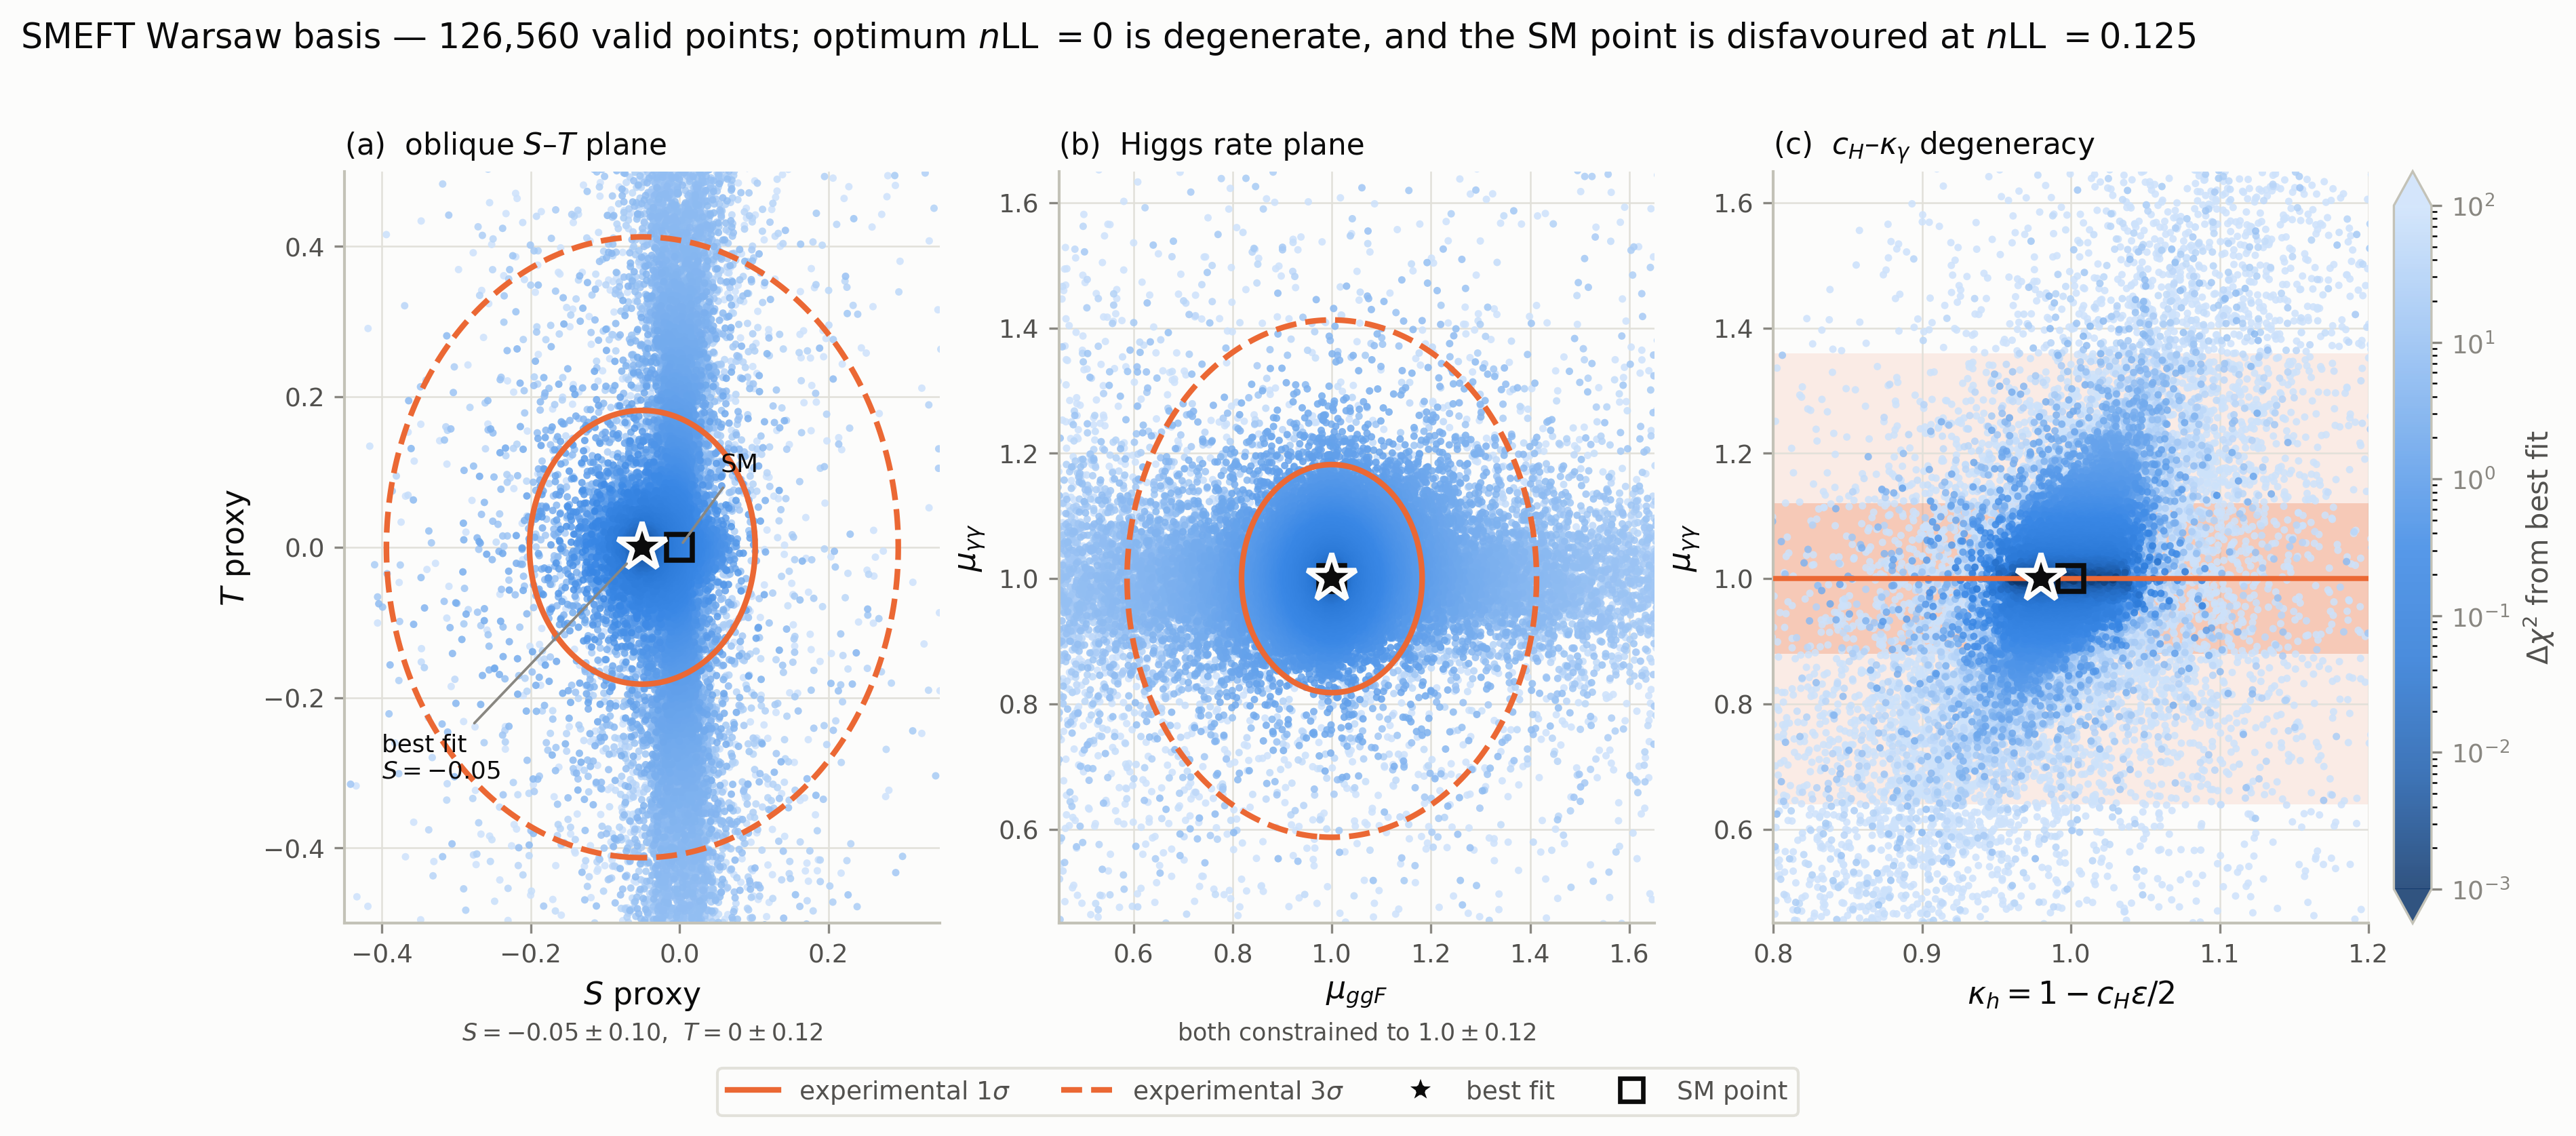

In [8]:
from IPython.display import Image, display
display(Image(filename="figures/smeft_wilson.png"))

The oblique-parameter fit and the kappa-framework degeneracy: mu_gammagamma stays pinned at 1 across a broad range of kappa_h.

## 6. Caveats

The $S$ and $T$ expressions are leading-order in $\varepsilon=(v/\Lambda)^2$ and only four operators are constrained while ten are scanned, which is precisely why the degeneracy is so large. This is a compact proxy, not a global SMEFT fit; before publication these should be checked against `wilson`/`flavio`, SMEFTsim or SMEFiT conventions.

## 7. Reproducing the full study

The cell below is exactly the pattern used to produce the table in section 4 — shown, not executed, since a full matched-budget run can take a while.

In [ ]:
# NOT executed in this notebook (can take from seconds to several minutes per
# engine). Reproduces the matched-budget comparison from the study: seed
# 20260816, ~30k evaluations, one row per engine.
rows = []
for engine in ["serial_random", "de_scipy", "adaptive_diver", "basin_scan"]:
    m = load_model("../models/smeft_wilson/model.yaml")
    m.scan.engine = engine
    m.scan.seed = 20260816
    m.scan.settings["max_evaluations"] = 30000
    c = compile_model(m)
    r = run_scan(m, c, run_directory=f"runs/{engine}_matched")
    rows.append({"engine": engine, **r.summary})
pd.DataFrame(rows)

---
BSMScanner: a declarative parameter-scanning framework for BSM physics. See the companion paper for the full seven-benchmark methodology study, and `notebooks/t43i_b1.ipynb` for a worked physics application built on top of it.